# Training the Models

### Overview

This notebook will guide you through the process of training both the fully connected network and graph neural net using a DataConfig object.

### Imports

Below are all the needed imports for training! This should take around a minute.

In [1]:
# general
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)

# local imports
import gnn
from gnn_model import GraphModel
import fcn
from fcn_model import FlowModel
from helpers import *

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"This notebook is using: {device}")

This notebook is using: cuda


### Loading the Data

Here you can modify some variables to customize as you wish. This notebook will specifically walk through training the GNN on Astrid, but nothing changes if you decide to train something else!

Data Paths
- <span style="color:pink">*data_dir*</span> (str): path to the highest level directory where you're storing your data.
- <span style="color:pink">*model_dir*</span> (str): path to the highest level directory you want to *save* your models at.

Simulation, Redshift, Model.
- <span style="color:pink"> *sim*</span> (str): Simulation suites (Astrid and Illustris)
- <span style="color:pink"> *z*</span> (int): Redshifts (3-6)
- <span style="color:pink"> *model_type*</span> (str): Either the GNN or FCN

Optional:
- <span style="color:hotpink"> *observables_only*</span>: If you set this to true, you will retrieve the models trained only on observables (i.e. JWST frequencies)

In [6]:
boxsizes = {
    'TNG': 75.,
    'ASTRID': 250.,
}
graph_radius = 2000

# TODO modify these paths 
data_dir = "/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/carol_processed_data/"
model_dir = "/n/home03/hbrittain/model_outs"

sim = 'tng'
z = 5
model_type = 'gnn'
observable_features_only = False
batch_size = 64

config = DataConfig(
    data_dir=data_dir,
    ckpt_dir=model_dir,
    model_type=model_type,
    sim=sim,
    z=z,
    graph_radius=graph_radius,
    observables_only=observable_features_only
    )

train_loader, val_loader, _ = load_data(config, batch_size=batch_size)

In [7]:
len(train_loader)

130

### Training
Great, now that the data is loaded, use your desired model (either <span style="color:dodgerblue">gnn.py</span> or <span style="color:dodgerblue">fcn.py</span>) and train the model :) 

For reference, our smallest dataset, Illustris at redshift 6, should train in less than 5 minutes (usually around a minute)
Our largest dataset, Astrid at redshift 3, may take a couple hours (around 2)

In [8]:
model, ckpt = gnn.train(config, train_loader, val_loader, max_steps = 200)

# model, ckpt = fcn.train(config, train_loader, val_loader, max_steps = 1_000)

/n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: helenabrittain (helenabri

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | GraphNetwork | 270 K  | train
1 | flow  | MAF          | 225 K  | train
-----------------------------------------------
495 K     Trainable params
0         Non-trainable params
495 K     Total params
1.983     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 0.553
Epoch 0, global step 130: 'val_loss' reached 0.55290 (best 0.55290), saving model to '/n/home03/hbrittain/model_outs/GNN_TNG_z5_target_HaloMass/best_gnn_TNG_z5_model-step=130-val_loss=0.55-mse_loss=0.18.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 0.522
Epoch 1, global step 195: 'val_loss' reached 0.52192 (best 0.52192), saving model to '/n/home03/hbrittain/model_outs/GNN_TNG_z5_target_HaloMass/best_gnn_TNG_z5_model-step=195-val_loss=0.52-mse_loss=0.17.ckpt' as top 1
`Trainer.fit` stopped: `max_steps=200` reached.


Best model saved at: /n/home03/hbrittain/model_outs/GNN_TNG_z5_target_HaloMass/best_gnn_TNG_z5_model-step=195-val_loss=0.52-mse_loss=0.17.ckpt
<class 'str'>


epoch,▁▁▁▁███
learning_rate_epoch,█▁
learning_rate_step,▁▁
lr-Adam,▁▁
mse_loss,█▂▁
train_loss,█▁
trainer/global_step,▁▁▃▄▄▄▆▆▆████
val_loss,█▄▁
epoch,1
learning_rate_epoch,0.0005
learning_rate_step,0.0005


In [13]:
# ckpt = 'GNN_TNG_z6_target_HaloMass/best_gnn_TNGz6_model-step=64-val_loss=0.85-mse_loss=0.47.ckpt'
# model = GraphModel.load_from_checkpoint(config.ckpt_dir / ckpt)
true, pred, log_prob = get_predictions(config, val_loader, model)

/n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Text(0, 0.5, 'Predicted halo masses')

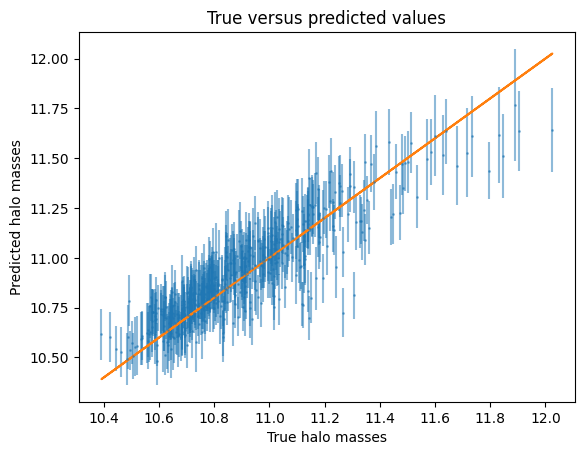

In [14]:
import matplotlib.pyplot as plt

plt.errorbar(x=true.cpu().numpy(),
             y=pred.cpu().numpy().mean(axis=1),
             yerr=pred.cpu().numpy().std(axis=1),
             marker='o',
             linestyle='',
             markersize=1,
             alpha=0.5)
plt.plot(true.cpu().numpy(), true.cpu().numpy())
plt.title('True versus predicted values')
plt.xlabel('True halo masses')
plt.ylabel('Predicted halo masses')

In [15]:
def compute_hmf_with_uncertainties(
    true_masses, 
    predicted_mass_samples, 
    volume, 
    bins=20, 
    mass_range=(10, 13),
):

    mass_bins = np.linspace(mass_range[0], mass_range[1], bins+1)
    bin_centers = (mass_bins[1:] + mass_bins[:-1]) / 2
    bin_widths = mass_bins[1:] - mass_bins[:-1]
    
    counts, _ = np.histogram(true_masses, bins=mass_bins)
    true_hmf = counts / (volume * bin_widths)  
    #true_hmf_errs = np.sqrt(counts) / (volume * bin_widths)  # Poisson errors, might want to include in the future?
    
    n_samples = predicted_mass_samples.shape[0]
    sample_hmfs = np.zeros((n_samples, bins))
    
    for i in range(n_samples):
        counts, _ = np.histogram(predicted_mass_samples[i], bins=mass_bins)
        sample_hmfs[i] = counts / (volume * bin_widths)
    
    
    pred_hmf = np.median(sample_hmfs, axis=0)
    pred_hmf_lower = np.percentile(sample_hmfs, 16, axis=0)
    pred_hmf_upper = np.percentile(sample_hmfs, 84, axis=0)
    
    return bin_centers, true_hmf, pred_hmf, pred_hmf_lower, pred_hmf_upper

def plot_hmf_comparison(bin_centers, true_hmf, 
                       pred_hmf, pred_hmf_lower, pred_hmf_upper):
    """Plot comparison between true and predicted HMFs with uncertainties"""
    plt.figure(figsize=(10, 6))
    
    
    plt.plot(bin_centers, pred_hmf, linestyle='-', color='indianred', label='Predicted HMF')
    plt.fill_between(bin_centers, pred_hmf_lower, pred_hmf_upper, 
                    color='indianred', alpha=0.3, label=r'$1\sigma$ confidence')
    
    plt.plot(bin_centers, true_hmf, color='black', label='True HMF', linewidth=2, linestyle='-')
    plt.yscale('log')
    plt.xlabel(r'log$_{10}$ (M$_{200c}$/M$_{\odot}$)')
    plt.ylabel(r'dn/dlog$_{10}$M [Mpc$^{-3}$]')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    return plt.gca()


In [16]:
bin_centers, true_hmf, pred_hmf, pred_hmf_lower, pred_hmf_upper = compute_hmf_with_uncertainties(true.cpu().numpy(), pred.cpu().numpy().T, volume=75_000)

<Axes: xlabel='log$_{10}$ (M$_{200c}$/M$_{\\odot}$)', ylabel='dn/dlog$_{10}$M [Mpc$^{-3}$]'>

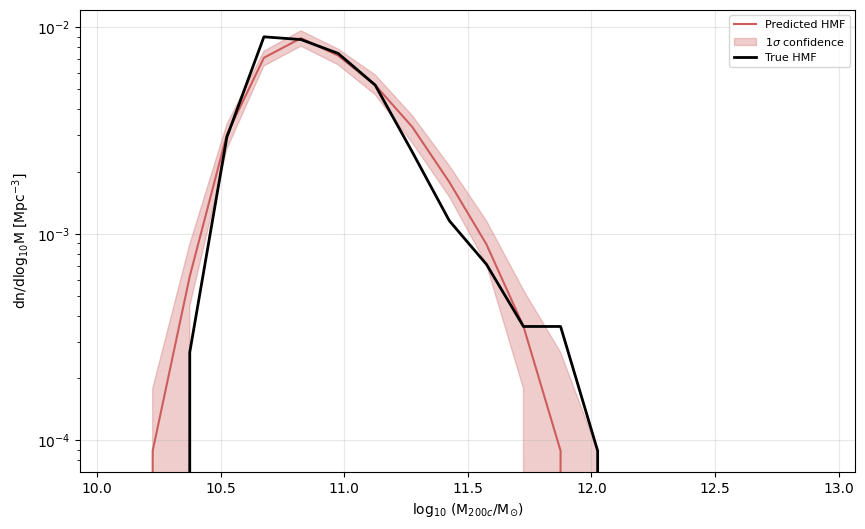

In [17]:
plot_hmf_comparison(bin_centers, true_hmf, pred_hmf, pred_hmf_lower, pred_hmf_upper)

In [18]:
def lampe_pairs(config, dataloader, model) -> zip:
    '''
    Generate parameter and posterior pairs 
    '''
    model.to(device)
    thetas = [] 
    exes = []  
    
    if config.model_type=='GNN':
        for batch in dataloader:
            batch = batch.to(device)
            thetas.append(batch.y)
            exes.append(model.model(batch))
    elif config.model_type=='FCN':
        for batch in dataloader:
            batch = batch.to(device)
            thetas.append(batch[1])
            exes.append(batch[0])
            
    theta = torch.cat(thetas, dim=0).unsqueeze(-1)
    x = torch.cat(exes, dim=0)
    return zip(theta, x)

pairs_val = lampe_pairs(config, dataloader=val_loader, model=model)
lvls_val, cvrs_val = expected_coverage_mc(model.flow, pairs_val)
# coverage_plot(lvls_val, cvrs_val)

pairs_train = lampe_pairs(config, dataloader=train_loader, model=model)
lvls_train, cvrs_train = expected_coverage_mc(model.flow, pairs_train)
# coverage_plot(lvls_train, cvrs_train)


436pair [00:01, 426.90pair/s]
8265pair [00:19, 429.48pair/s]


Text(0.5, 0.98, 'Coverage plot for GNN, train versus val')

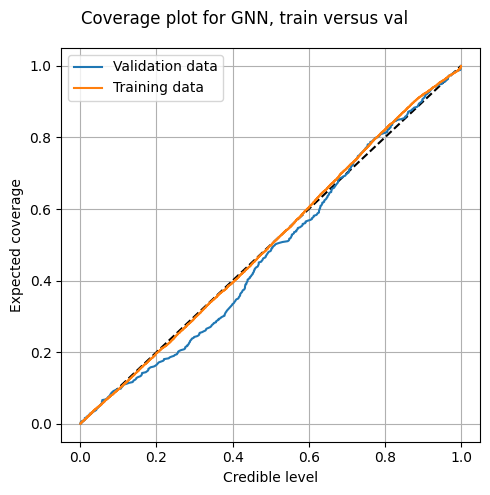

In [19]:
fig = coverage_plot(lvls_val, cvrs_val, legend=f'Validation data', figsize=(5,5))
coverage_plot(lvls_train, cvrs_train, legend=f'Training data', figure=fig)
fig.suptitle(f"Coverage plot for GNN, train versus val")   
# fig(figsize=(10,6))